# HW03 Problem 2: FashionMNIST Image Classifier with PyTorch

**Sonica Sahetiya**

This notebook builds, trains and evaluates a multilayer perceptron (MLP) that classifies
FashionMNIST images into 10 clothing categories. It follows the *Building an Image Classifier
with PyTorch* section of the reference notebook `10_neural_nets_with_pytorch.ipynb`.

Workflow:
1. Setup: imports and device selection
2. Load FashionMNIST and split it into training, validation and test sets
3. Create DataLoaders
4. Define the classifier
5. Train and evaluate it
6. Plot training accuracy by epoch
7. Predict classes for a few validation images

The notebook is self-contained: restart the kernel and run all cells from top to bottom.

## 1. Setup

All imports for the notebook are collected here. The code then selects the fastest available
device: an NVIDIA GPU (CUDA), an Apple Silicon GPU (MPS), or the CPU.

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: cpu


## 2. Load the FashionMNIST dataset

TorchVision downloads FashionMNIST into `datasets/` on first use. The `toTensor` transform turns
each 28×28 grayscale image into a `float32` tensor of shape `[1, 28, 28]` with pixel values
scaled to [0, 1].

FashionMNIST provides 60,000 training images and 10,000 test images. With a random seed of 42,
the 60,000 training images are split into **55,000 for training** and **5,000 for validation**.
The validation set is used to monitor the model during training; the test set stays untouched.

In [2]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

print(f"Train: {len(train_data)}, valid: {len(valid_data)}, test: {len(test_data)}")

Train: 55000, valid: 5000, test: 10000


## 3. Create DataLoaders

DataLoaders feed the data to the model in batches of 32. Only the training data is shuffled,
so each epoch sees the training images in a new order, while the validation and test order
stays fixed. The seed is set again so the shuffling is reproducible.

In [3]:
torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

Each dataset entry is an `(image, target)` tuple. A quick check of one training image shows its
shape, `[channels, rows, columns]`, and its FashionMNIST class:

In [4]:
X_sample, y_sample = train_data[0]
print(f"Image shape: {tuple(X_sample.shape)}")
print(f"Class: {train_and_valid_data.classes[y_sample]}")

Image shape: (1, 28, 28)
Class: Ankle boot


## 4. Define the image classifier

`ImageClassifier` is an MLP built with `nn.Sequential`:

- `nn.Flatten()` turns each `1×28×28` image into a vector of 784 pixel values
- a fully connected layer with **300** hidden units, then ReLU
- a fully connected layer with **100** hidden units, then ReLU
- an output layer with **10** units, one logit per class

The model outputs raw logits; `CrossEntropyLoss` applies softmax internally during training.
The seed is set to 42 before creating the model so the initial weights are reproducible.

In [5]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)


torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)

print(model)
print(f"Parameters: {sum([param.numel() for param in model.parameters()]):,}")

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Parameters: 266,610


## 5. Train and evaluate the classifier

Two functions from the reference notebook handle training and evaluation:

- `evaluate_tm()` puts the model in evaluation mode and computes a torchmetrics metric over a
  whole DataLoader without tracking gradients.
- `train2()` runs the training loop. For every epoch it records the **mean training loss**,
  the **training accuracy** (accumulated over the epoch's batches) and the **validation
  accuracy** (computed with `evaluate_tm()` at the end of the epoch), and returns them in a
  `history` dictionary.

In [6]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end


def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train accuracy: {history['train_metrics'][-1]:.4f}, "
              f"valid accuracy: {history['valid_metrics'][-1]:.4f}")
    return history

The model is trained for 20 epochs with:

- **Loss:** `nn.CrossEntropyLoss`, the standard loss for multiclass classification
- **Optimizer:** stochastic gradient descent (SGD) with a learning rate of 0.1
- **Metric:** torchmetrics multiclass accuracy over the 10 classes

In [7]:
n_epochs = 20
xentropy = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

history = train2(model, optimizer, xentropy, accuracy, train_loader,
                 valid_loader, n_epochs)

Epoch 1/20, train loss: 0.6060, train accuracy: 0.7814, valid accuracy: 0.8424


Epoch 2/20, train loss: 0.4061, train accuracy: 0.8496, valid accuracy: 0.8402


Epoch 3/20, train loss: 0.3630, train accuracy: 0.8661, valid accuracy: 0.8494


Epoch 4/20, train loss: 0.3355, train accuracy: 0.8768, valid accuracy: 0.8638


Epoch 5/20, train loss: 0.3154, train accuracy: 0.8829, valid accuracy: 0.8782


...

Epoch 16/20, train loss: 0.2078, train accuracy: 0.9196, valid accuracy: 0.8886


Epoch 17/20, train loss: 0.2033, train accuracy: 0.9233, valid accuracy: 0.8870


Epoch 18/20, train loss: 0.1991, train accuracy: 0.9230, valid accuracy: 0.8846


Epoch 19/20, train loss: 0.1916, train accuracy: 0.9266, valid accuracy: 0.8812


Epoch 20/20, train loss: 0.1876, train accuracy: 0.9286, valid accuracy: 0.8788


## 6. Plot training accuracy by epoch

The training accuracy recorded for each epoch in `history["train_metrics"]` is plotted below.

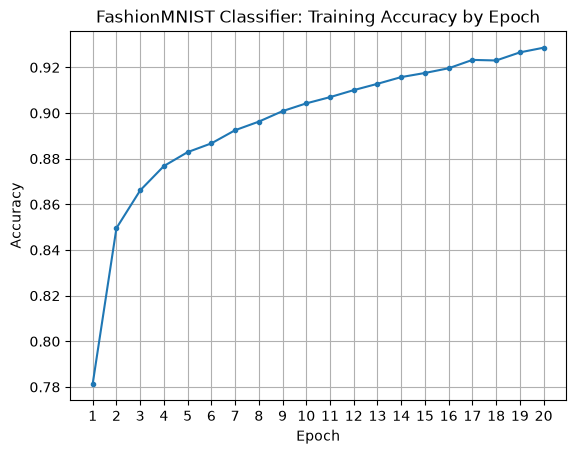

In [8]:
train_accuracy = history["train_metrics"]
epochs = range(1, len(train_accuracy) + 1)

plt.plot(epochs, train_accuracy, ".-")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("FashionMNIST Classifier: Training Accuracy by Epoch")
plt.xticks(epochs)
plt.grid()
plt.show()

Training accuracy rises quickly in the first few epochs and then keeps improving more slowly.
Validation accuracy (printed in the training log above) levels off at around 0.88 after roughly
a dozen epochs while training accuracy keeps climbing, a sign that the model is starting to
overfit the training data.

## 7. Predict classes for validation images

The trained model is used to classify the first three images of a validation batch. The model
is switched to evaluation mode and gradients are disabled. The predicted class is the index of
the largest logit, which is converted to its FashionMNIST class name and compared with the true
label.

In [9]:
classes = train_and_valid_data.classes

model.eval()
X_new, y_new = next(iter(valid_loader))
X_new, y_new = X_new[:3].to(device), y_new[:3]
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1).cpu()  # index of the largest logit

print(f"Predicted indices: {y_pred.tolist()}")
print(f"True indices:      {y_new.tolist()}")
print(f"Predicted classes: {[classes[index] for index in y_pred]}")
print(f"True classes:      {[classes[index] for index in y_new]}")

Predicted indices: [7, 4, 2]
True indices:      [7, 4, 2]
Predicted classes: ['Sneaker', 'Coat', 'Pullover']
True classes:      ['Sneaker', 'Coat', 'Pullover']


Softmax turns the logits into class probabilities that sum to 1 for each image, showing how
confident the model is in each prediction. The probabilities are moved to the CPU before
printing (needed on MPS).

In [10]:
y_proba = F.softmax(y_pred_logits, dim=1).cpu()

for i, (pred, true) in enumerate(zip(y_pred, y_new)):
    result = "correct" if pred == true else "WRONG"
    print(f"Image {i}: predicted {classes[pred]!r} (p={y_proba[i, pred]:.3f}), "
          f"true {classes[true]!r} -> {result}")

print("\nSoftmax probabilities:")
print(f"{'Class':<14}" + "".join(f"{f'Image {i}':>10}" for i in range(len(y_proba))))
for index, name in enumerate(classes):
    print(f"{name:<14}" + "".join(f"{p:>10.3f}" for p in y_proba[:, index]))

Image 0: predicted 'Sneaker' (p=0.859), true 'Sneaker' -> correct
Image 1: predicted 'Coat' (p=0.993), true 'Coat' -> correct
Image 2: predicted 'Pullover' (p=0.592), true 'Pullover' -> correct

Softmax probabilities:
Class            Image 0   Image 1   Image 2
T-shirt/top        0.000     0.000     0.004
Trouser            0.000     0.000     0.000
Pullover           0.000     0.007     0.592
Dress              0.000     0.000     0.000
Coat               0.000     0.993     0.212
Sandal             0.000     0.000     0.000
Shirt              0.000     0.000     0.191
Sneaker            0.859     0.000     0.000
Bag                0.000     0.000     0.001
Ankle boot         0.141     0.000     0.000


## Conclusion

The MLP (784 → 300 → 100 → 10, 266,610 parameters) reaches about 93% training accuracy and
about 88% validation accuracy after 20 epochs of SGD. Its predictions for the three sample
validation images are correct. The softmax probabilities show that it is less certain when
visually similar classes compete, such as Pullover, Coat and Shirt.